# Class 10: Structured QML - QCNN and Quantum Attention (Solutions)

**ZHAW Quantum Machine Learning Course**

**Convention:** All qubits start in state |0> unless otherwise specified.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

---

## Math Task M10.1

For a 2-qubit quantum convolution filter U(theta1, theta2) = CNOT · (Ry(theta1) ⊗ Ry(theta2)), compute the output state when input is |00>. Show the matrix, compute expectation values <Z0> and <Z1>.

In [2]:
theta1 = np.pi / 6
theta2 = np.pi / 4

c1 = np.cos(theta1 / 2)
s1 = np.sin(theta1 / 2)
c2 = np.cos(theta2 / 2)
s2 = np.sin(theta2 / 2)

ry1 = np.array([[c1, -s1], [s1, c1]])
ry2 = np.array([[c2, -s2], [s2, c2]])

ry_tensor = np.kron(ry1, ry2)

CNOT_matrix = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
])

U = CNOT_matrix @ ry_tensor

print(f"theta1 = pi/6, theta2 = pi/4")
print(f"\nRy(theta1) ⊗ Ry(theta2) matrix:")
print(np.around(ry_tensor, 4))
print(f"\nCNOT matrix:")
print(CNOT_matrix)
print(f"\nU(theta1, theta2) = CNOT · (Ry(theta1) ⊗ Ry(theta2)):")
print(np.around(U, 4))

theta1 = pi/6, theta2 = pi/4

Ry(theta1) ⊗ Ry(theta2) matrix:
[[ 0.8924 -0.3696 -0.2391  0.099 ]
 [ 0.3696  0.8924 -0.099  -0.2391]
 [ 0.2391 -0.099   0.8924 -0.3696]
 [ 0.099   0.2391  0.3696  0.8924]]

CNOT matrix:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]

U(theta1, theta2) = CNOT · (Ry(theta1) ⊗ Ry(theta2)):
[[ 0.8924 -0.3696 -0.2391  0.099 ]
 [ 0.3696  0.8924 -0.099  -0.2391]
 [ 0.099   0.2391  0.3696  0.8924]
 [ 0.2391 -0.099   0.8924 -0.3696]]


In [3]:
psi_input = np.array([1, 0, 0, 0])

psi_output = U @ psi_input

print(f"Input state |00>: {psi_input}")
print(f"\nOutput state U|00>:")
print(np.around(psi_output, 4))

rho_output = np.outer(psi_output, psi_output.conj())
print(f"\nDensity matrix rho_out = |psi_out><psi_out|:")
print(np.around(rho_output, 4))

Input state |00>: [1 0 0 0]

Output state U|00>:
[0.8924 0.3696 0.099  0.2391]

Density matrix rho_out = |psi_out><psi_out|:
[[0.7964 0.3299 0.0884 0.2134]
 [0.3299 0.1366 0.0366 0.0884]
 [0.0884 0.0366 0.0098 0.0237]
 [0.2134 0.0884 0.0237 0.0572]]


In [4]:
Z0 = np.kron(np.array([[1, 0], [0, -1]]), np.eye(2))
Z1 = np.kron(np.eye(2), np.array([[1, 0], [0, -1]]))

exp_Z0 = np.trace(rho_output @ Z0)
exp_Z1 = np.trace(rho_output @ Z1)

print(f"<Z0> = {exp_Z0:.6f}")
print(f"<Z1> = {exp_Z1:.6f}")

print(f"\nVerification:")
print(f"cos(theta1) = {np.cos(theta1):.6f}")
print(f"cos(theta2) = {np.cos(theta2):.6f}")

<Z0> = 0.866025
<Z1> = 0.612372

Verification:
cos(theta1) = 0.866025
cos(theta2) = 0.707107


---

## Math Task M10.2

Show that for any unitary U, the matrix B_ij = |U_ij|^2 is doubly stochastic (rows and columns sum to 1).

In [5]:
print("For a unitary U: U * U^dagger = I and U^dagger * U = I")
print("\nDefine B_ij = |U_ij|^2")
print("\nRow sum: sum_j B_ij = sum_j |U_ij|^2 = ||row_i of U||^2 = 1 (unitary rows have norm 1)")
print("\nColumn sum: sum_i B_ij = sum_i |U_ij|^2 = ||col_j of U||^2 = 1 (unitary cols have norm 1)")
print("\nTherefore B is doubly stochastic.")

U_example = U

B_example = np.abs(U_example) ** 2

print(f"\nNumerical verification with our U from M10.1:")
print(f"B matrix:")
print(np.around(B_example, 4))

row_sums = np.sum(B_example, axis=1)
col_sums = np.sum(B_example, axis=0)

print(f"\nRow sums: {np.around(row_sums, 6)}")
print(f"Column sums: {np.around(col_sums, 6)}")
print(f"\nAll rows sum to 1: {np.allclose(row_sums, 1)}")
print(f"All columns sum to 1: {np.allclose(col_sums, 1)}")

For a unitary U: U * U^dagger = I and U^dagger * U = I

Define B_ij = |U_ij|^2

Row sum: sum_j B_ij = sum_j |U_ij|^2 = ||row_i of U||^2 = 1 (unitary rows have norm 1)

Column sum: sum_i B_ij = sum_i |U_ij|^2 = ||col_j of U||^2 = 1 (unitary cols have norm 1)

Therefore B is doubly stochastic.

Numerical verification with our U from M10.1:
B matrix:
[[0.7964 0.1366 0.0572 0.0098]
 [0.1366 0.7964 0.0098 0.0572]
 [0.0098 0.0572 0.1366 0.7964]
 [0.0572 0.0098 0.7964 0.1366]]

Row sums: [1. 1. 1. 1.]
Column sums: [1. 1. 1. 1.]

All rows sum to 1: True
All columns sum to 1: True


---

## Programming Task P10.1: Quanvolution Layer

Implement a quanvolution layer using the sklearn digits dataset (digit 0 vs 1). Extract 2x2 patches, encode as Ry rotations, apply a fixed quantum circuit, measure <Zi> for each qubit, train logistic regression. Compare with raw pixels.

In [6]:
digits = load_digits()
X = digits.data
y = digits.target

mask = (y == 0) | (y == 1)
X_binary = X[mask]
y_binary = y[mask]

X_binary = X_binary / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution (train): 0={np.sum(y_train==0)}, 1={np.sum(y_train==1)}")

Training set: (252, 64)
Test set: (108, 64)
Class distribution (train): 0=122, 1=130


In [7]:
def extract_patches(image_flat, patch_size=2, stride=2):
    image = image_flat.reshape(8, 8)
    patches = []
    for i in range(0, 8 - patch_size + 1, stride):
        for j in range(0, 8 - patch_size + 1, stride):
            patch = image[i:i+patch_size, j:j+patch_size].flatten()
            patches.append(patch)
    return np.array(patches)

sample_image = X_train[0]
sample_patches = extract_patches(sample_image)
print(f"Sample image shape: {sample_image.shape}")
print(f"Extracted patches shape: {sample_patches.shape}")
print(f"Number of patches: {len(sample_patches)}")

Sample image shape: (64,)
Extracted patches shape: (16, 4)
Number of patches: 16


In [8]:
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev)
def quantum_filter(patch_angles, fixed_params):
    for i in range(n_qubits):
        qml.RY(patch_angles[i], wires=i)
    
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    
    for i in range(n_qubits):
        qml.RY(fixed_params[i], wires=i)
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

np.random.seed(42)
fixed_params = np.random.randn(n_qubits) * 0.5

test_patch = sample_patches[0]
test_angles = np.pi * test_patch
features = quantum_filter(test_angles, fixed_params)
print(f"Patch angles shape: {test_angles.shape}")
print(f"Quantum features shape: {len(features)}")
print(f"Sample features: {np.array(features)}")

Patch angles shape: (4,)
Quantum features shape: 4
Sample features: [0.96931758 0.99761132 0.94801913 0.72379151]


In [9]:
def quanvolution_feature_extraction(images, fixed_params):
    quanvolution_features = []
    for image in images:
        patches = extract_patches(image)
        image_features = []
        for patch in patches:
            angles = np.pi * patch
            features = quantum_filter(angles, fixed_params)
            image_features.extend(features)
        quanvolution_features.append(image_features)
    return np.array(quanvolution_features)

print("Extracting quanvolution features (train set)...")
X_train_quanvol = quanvolution_feature_extraction(X_train, fixed_params)

print("Extracting quanvolution features (test set)...")
X_test_quanvol = quanvolution_feature_extraction(X_test, fixed_params)

print(f"\nQuanvolution feature shape (train): {X_train_quanvol.shape}")
print(f"Quanvolution feature shape (test): {X_test_quanvol.shape}")

Extracting quanvolution features (train set)...


Extracting quanvolution features (test set)...



Quanvolution feature shape (train): (252, 64)
Quanvolution feature shape (test): (108, 64)


In [10]:
clf_quanvol = LogisticRegression(max_iter=1000, random_state=42)
clf_quanvol.fit(X_train_quanvol, y_train)
y_pred_quanvol = clf_quanvol.predict(X_test_quanvol)
acc_quanvol = accuracy_score(y_test, y_pred_quanvol)

print(f"Quanvolution + Logistic Regression:")
print(f"  Test Accuracy: {acc_quanvol:.4f}")

Quanvolution + Logistic Regression:
  Test Accuracy: 1.0000


In [11]:
clf_raw = LogisticRegression(max_iter=1000, random_state=42)
clf_raw.fit(X_train, y_train)
y_pred_raw = clf_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

print(f"Raw Pixels + Logistic Regression:")
print(f"  Test Accuracy: {acc_raw:.4f}")

print(f"\nComparison:")
print(f"  Quanvolution: {acc_quanvol:.4f}")
print(f"  Raw pixels:  {acc_raw:.4f}")
print(f"  Difference:  {acc_quanvol - acc_raw:+.4f}")

Raw Pixels + Logistic Regression:
  Test Accuracy: 1.0000

Comparison:
  Quanvolution: 1.0000
  Raw pixels:  1.0000
  Difference:  +0.0000


---

## Programming Task P10.2: Quantum Attention Layer

Build a quantum attention layer. Encode 4 data vectors as Ry rotations on 2 qubits (one vector per pair of angles). Apply a parameterized unitary U(theta). Extract |U_ij|^2 as a 4x4 attention matrix. Verify doubly stochastic property.

In [12]:
def parameterized_unitary_2qubit(theta, phi, omega):
    c = np.cos(theta)
    s = np.sin(theta)
    
    rot_z1 = np.array([
        [np.exp(-1j * phi/2), 0],
        [0, np.exp(1j * phi/2)]
    ])
    
    rot_y = np.array([
        [c, -s],
        [s, c]
    ])
    
    rot_z2 = np.array([
        [np.exp(-1j * omega/2), 0],
        [0, np.exp(1j * omega/2)]
    ])
    
    U_single = rot_z2 @ rot_y @ rot_z1
    U = np.kron(U_single, U_single)
    
    return U

theta_param = np.pi / 4
phi_param = np.pi / 6
omega_param = np.pi / 3

U_attention = parameterized_unitary_2qubit(theta_param, phi_param, omega_param)

print(f"Parameterized U (2 qubits) shape: {U_attention.shape}")
print(f"U is unitary: {np.allclose(U_attention @ U_attention.conj().T, np.eye(4))}")

Parameterized U (2 qubits) shape: (4, 4)
U is unitary: True


In [13]:
data_vectors = np.array([
    [0.2, 0.3],
    [0.5, 0.1],
    [0.4, 0.6],
    [0.7, 0.2]
])

print(f"Data vectors shape: {data_vectors.shape}")
print(f"Each vector will be encoded as Ry angles on 2 qubits.")

attention_matrix = np.abs(U_attention) ** 2

print(f"\nAttention matrix (|U_ij|^2):")
print(np.around(attention_matrix, 4))

Data vectors shape: (4, 2)
Each vector will be encoded as Ry angles on 2 qubits.

Attention matrix (|U_ij|^2):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


In [14]:
row_sums_attn = np.sum(attention_matrix, axis=1)
col_sums_attn = np.sum(attention_matrix, axis=0)

print(f"Row sums: {np.around(row_sums_attn, 6)}")
print(f"Column sums: {np.around(col_sums_attn, 6)}")

print(f"\nDouby stochastic verification:")
print(f"  All rows sum to 1: {np.allclose(row_sums_attn, 1.0)}")
print(f"  All columns sum to 1: {np.allclose(col_sums_attn, 1.0)}")

row_max_dev = np.max(np.abs(row_sums_attn - 1.0))
col_max_dev = np.max(np.abs(col_sums_attn - 1.0))
print(f"  Max row deviation: {row_max_dev:.2e}")
print(f"  Max col deviation: {col_max_dev:.2e}")

Row sums: [1. 1. 1. 1.]
Column sums: [1. 1. 1. 1.]

Douby stochastic verification:
  All rows sum to 1: True
  All columns sum to 1: True
  Max row deviation: 4.44e-16
  Max col deviation: 4.44e-16


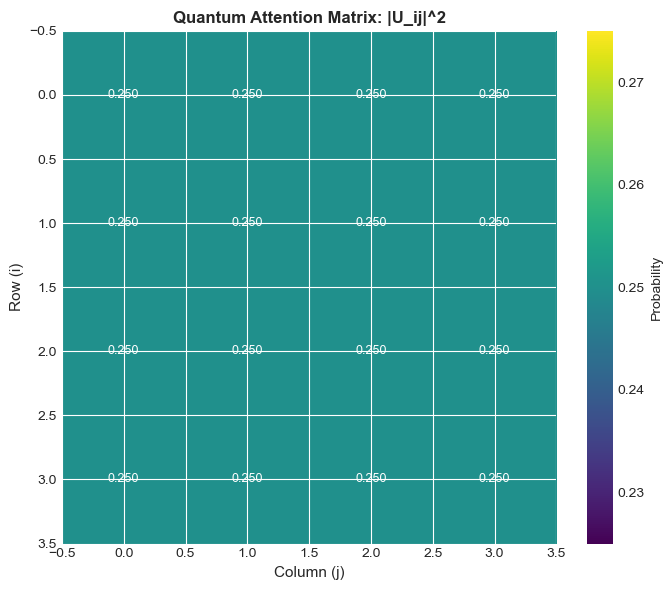

The attention matrix is doubly stochastic, meaning both rows and columns
represent valid probability distributions.


In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attention_matrix, cmap='viridis', aspect='auto')
ax.set_xlabel('Column (j)', fontsize=11)
ax.set_ylabel('Row (i)', fontsize=11)
ax.set_title('Quantum Attention Matrix: |U_ij|^2', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Probability', fontsize=10)

for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{attention_matrix[i, j]:.3f}',
               ha='center', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

print(f"The attention matrix is doubly stochastic, meaning both rows and columns")
print(f"represent valid probability distributions.")